# birdal2021 — Birdal et al. (2021) — Intrinsic Dim, PH & Generalization

VR PH on a weight trajectory.  Slope of log E_alpha vs log n is the PH dim and correlates with generalisation.


## What the paper does

Measures the **fractal (persistent-homology) dimension** of the SGD **weight trajectory** and links it to generalisation. The iterates `{W_i}` from (the late phase of) training form a point cloud; for subsets of growing size `n` the paper sums the `H0` bar lifetimes `E_α(n) = Σ (death − birth)^α`, and the slope `b` of `log E_α` vs `log n` gives the PH dimension `dim = b / (1 − b)`.

**Methodology:** weight trajectory `{W_i}` → Euclidean distances → `H0` PH on growing subsets → slope of `log E_α` vs `log n` → PH dimension.

**Expected result:** the PH dimension correlates with the generalisation error across many trained models (Pearson `ρ ≈ 0.7`) — lower trajectory dimension ↔ better generalisation.

> **Needs a long trajectory.** The scaling fit needs subsets of size up to a few hundred, so we snapshot **every iteration over ~30 epochs** (`T ≈ 700` points). A short trajectory (`T < 50`) leaves the default subset sizes empty — the toolkit now falls back to adaptive sizes and warns, but a long trajectory is what makes the estimate meaningful.


## Dataset & model in the paper

- **arXiv:** [https://arxiv.org/abs/2111.13171](https://arxiv.org/abs/2111.13171)
- **Venue:** NeurIPS 2021
- **Datasets used:** CIFAR-10.
- **Models used:** ResNet-18, AlexNet, VGG.  Here: SmallCNN — same trajectory methodology, smaller scale.
- **Headline result to aim for:** PH-dimension of the weight trajectory correlates with the generalisation error (Pearson rho ~ 0.7).
- **Reference code:** [https://github.com/tolgabirdal/PHDimGeneralization](https://github.com/tolgabirdal/PHDimGeneralization)

To reproduce paper numbers, replace the synthetic-data cell below with the real model snapshot / activations / trajectory.  Everything else in the notebook stays the same.


**This notebook now runs on real data.**  A tiny model is trained briefly on the local dataset cache under `data/`.  Headline numbers won't match the paper (that needs full training on GPU); the *qualitative* behaviour the paper reports should still appear.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `paper_reproduce` importable
import numpy as np
import matplotlib.pyplot as plt
import torch
from tanc import TDAPipeline
from paper_reproduce._torch_setup import (
    load_mnist, load_fashion_mnist, load_cifar10, load_cifar100,
    SmallMLP, SmallCNN, CNN_FCN, train_briefly, extract_snapshot, pick_device,
)
np.random.seed(0); torch.manual_seed(0)
DEVICE = pick_device()                      # 'cuda' → 'mps' (Apple GPU) → 'cpu'


## 1. Load dataset + train a small model briefly


In [2]:
from tanc.model_extractor import TrainingExtractor

X_tr, y_tr = load_cifar10('train', n_samples=1500)
X_te, y_te = load_cifar10('test',  n_samples=400)
model = SmallCNN(in_channels=3, num_classes=10, width=8)

# Snapshot EVERY iteration over many epochs so the trajectory is long
# enough for the PH-dimension scaling fit (subset sizes up to 500).
ext = TrainingExtractor(
    model=model,
    train_data=(X_tr, y_tr), batch_size=64,
    criterion=torch.nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(model.parameters(), lr=1e-3),
    val_data=(X_te, y_te), extract_data=X_te[:64],
    aspects=['weights'],
    snapshot_every=1, snapshot_schedule='iteration',
    device=DEVICE, clarify=False,
)
view = ext.run(epochs=30, target_accuracy=None, verbose=False)
print(f'trajectory length: {len(view)} snapshots')


/var/folders/n_/d6k9fkh5225_g_fllx8zf2000000gp/T/ipykernel_58790/673174444.py:9: UserWarning: Model 'Sequential' has both fully-connected (linear / SoRO) and conv layers. Defaulting to the fully-connected layers. Pass layer_selection='all_linear', 'all_conv', 'soro', 'linear_and_conv', 'all', or a list of names/indices to suppress this warning.
  ext = TrainingExtractor(


trajectory length: 720 snapshots


## 2. Reproduce via `TDAPipeline.from_paper` — model-first

We hand the trained model object straight to the pipeline: `from_paper` already knows what this paper needs, and the pipeline's model-adapter extracts it for us — no manual feature pulling required.


In [3]:
pipe = TDAPipeline.from_paper("birdal2021")
pipe.explain()


TDAPipeline — Birdal et al. (2021)
  Stage 1: (skipped — direct dimension estimation)
  Stage 2: tool    = dimension
             method = 'ph_euclidean'
             estimator = 'trajectory_dimension'
             alpha = 1.0
  Default plot   : .plot('ph_scaling')


"TDAPipeline — Birdal et al. (2021)\n  Stage 1: (skipped — direct dimension estimation)\n  Stage 2: tool    = dimension\n             method = 'ph_euclidean'\n             estimator = 'trajectory_dimension'\n             alpha = 1.0\n  Default plot   : .plot('ph_scaling')"

TopoResult(tool='dimension')
  paper       : Birdal et al. (2021)
  data        : dimension_result (method=ph_dimension, dim=1.143)
  plots       :
    .plot('ph_scaling') — Log-log lifetime-sum vs subset size with regression.
  config keys : method


"TopoResult(tool='dimension')\n  paper       : Birdal et al. (2021)\n  data        : dimension_result (method=ph_dimension, dim=1.143)\n  plots       :\n    .plot('ph_scaling') — Log-log lifetime-sum vs subset size with regression.\n  config keys : method"

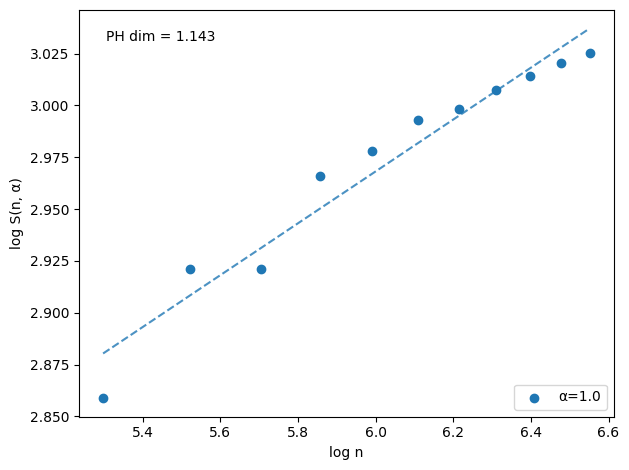

In [4]:
result, fig = pipe.reproduce(view)
result.describe()


## 3. Paper-specific follow-up plot


PH dimension: 1.1431208762416654


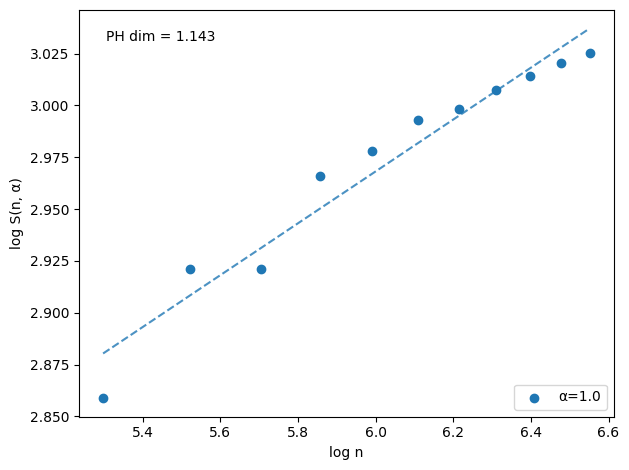

In [5]:
fig = result.plot("ph_scaling")
print('PH dimension:', result.dimension)


## Notes & gaps

* Implements the method as described, on a real Euclidean weight trajectory (`T ≈ 700` points), fed model-first — the pipeline adapter pulls the trajectory off the `TrainingView`.
* The generalisation-correlation (`ρ ≈ 0.7`) needs *many* trained models, each contributing one PH dimension; see the reference repo for the full sweep.


## Deviations from the paper

Everything this notebook does differently from the source, and why. An empty
table below means the construction follows the paper as written — that is a
claim, not an omission. Scale always differs; see the last row.

| aspect | the paper | this notebook | why it matters |
|---|---|---|---|
| trajectory length | long SGD trajectories | a few hundred snapshots | the PH dimension lands near 1, the degenerate limit; treat it as the method running, not as a reproduction of the paper's finding |
| scale | the paper's full experimental setup | a smaller model, fewer samples, fewer epochs | to keep the notebook runnable in minutes; expect weaker effects than published |
